# متدولوژی

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers,metrics
T_in=6
input_size=20
output_size=20
W_size=128
learning_rate=0.005
batch_size=64
dropout_rate=0.3

ss_markov_model=models.Sequential([
    layers.Input(shape=(T_in,input_size)),
    layers.Lambda(lambda x: x[:,-1,:]),
    layers.Dense(W_size,use_bias=True,activation='relu'), 
    layers.BatchNormalization(),
    layers.Dense(output_size)])

ss_markov_model.compile(
    optimizer=optimizers.Adam(learning_rate=learning_rate),
    loss='mse',
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')])
ss_markov_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)                    │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │           2,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 20)                  │           2,580 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,780 (22.58 KB)

 Trainable params: 5,524 (21.58 KB)

 Non-trainable params: 256 (1.00 KB)

In [3]:
timesteps=T_in
dense_size=128
fc_dropout=0.3

inputs=layers.Input(shape=(timesteps,input_size))
x=layers.GRU(W_size,return_sequences=True,
        dropout=dropout_rate,recurrent_dropout=dropout_rate)(inputs)

x=layers.BatchNormalization()(x)
x=layers.TimeDistributed(layers.Dense(dense_size,activation='relu'))(x)   

outputs=layers.TimeDistributed(layers.Dense(output_size))(x)

GRU_model=models.Model(inputs=inputs,outputs=outputs)
GRU_model.compile(
    optimizer=optimizers.Adam(learning_rate=learning_rate),
    loss='mse',
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')])

GRU_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 6, 20)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (None, 6, 128)              │          57,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 6, 128)              │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 6, 128)              │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed) │ (None, 6, 20)               │           2,580 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 77,204 (301.58 KB)

 Trainable params: 76,948 (300.58 KB)

 Non-trainable params: 256 (1.00 KB)

In [51]:
inputs=layers.Input(shape=(timesteps,input_size))
x=layers.Bidirectional(layers.GRU(W_size,return_sequences=True,
                    dropout=dropout_rate,recurrent_dropout=dropout_rate))(inputs)

x=layers.BatchNormalization()(x)
x=layers.TimeDistributed(layers.Dense(dense_size,activation='relu'))(x)   

outputs=layers.TimeDistributed(layers.Dense(output_size))(x)

Bidirectional_GRU_model=models.Model(inputs=inputs,outputs=outputs)
Bidirectional_GRU_model.compile(
    optimizer=optimizers.Adam(learning_rate=learning_rate),
    loss='mse',
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')])

Bidirectional_GRU_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)          │ (None, 6, 20)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 6, 256)              │         115,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 6, 256)              │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_10                  │ (None, 6, 128)              │          32,896 │
│ (TimeDistributed)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_11                  │ (None, 6, 20)               │           2,580 │
│ (TimeDistributed)                    │                             │                 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151,700 (592.58 KB)

 Trainable params: 151,188 (590.58 KB)

 Non-trainable params: 512 (2.00 KB)

In [6]:
inputs=layers.Input(shape=(timesteps,input_size))
x=layers.LSTM(W_size,return_sequences=True,
        dropout=dropout_rate,recurrent_dropout=dropout_rate)(inputs)

x=layers.BatchNormalization()(x)

x=layers.TimeDistributed(layers.Dense(dense_size,activation='relu'))(x)   

outputs=layers.TimeDistributed(layers.Dense(output_size))(x)

LSTM_model=models.Model(inputs=inputs,outputs=outputs)
LSTM_model.compile(
    optimizer=optimizers.Adam(learning_rate=learning_rate),
    loss='mse',
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')])

LSTM_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 6, 20)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 6, 128)              │          76,288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 6, 128)              │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_6 (TimeDistributed) │ (None, 6, 128)              │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_7 (TimeDistributed) │ (None, 6, 20)               │           2,580 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 95,892 (374.58 KB)

 Trainable params: 95,636 (373.58 KB)

 Non-trainable params: 256 (1.00 KB)

In [52]:
inputs=layers.Input(shape=(timesteps,input_size))
x=layers.Bidirectional(layers.LSTM(W_size,return_sequences=True,
                    dropout=dropout_rate,recurrent_dropout=dropout_rate))(inputs)

x=layers.BatchNormalization()(x)
x=layers.TimeDistributed(layers.Dense(dense_size,activation='relu'))(x)   
#x=layers.Dropout(fc_dropout)(x)

outputs=layers.TimeDistributed(layers.Dense(output_size))(x)

Bidirectional_LSTM_model=models.Model(inputs=inputs,outputs=outputs)
Bidirectional_LSTM_model.compile(
    optimizer=optimizers.Adam(learning_rate=learning_rate),
    loss='mse',
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')])

Bidirectional_LSTM_model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)          │ (None, 6, 20)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_4 (Bidirectional)      │ (None, 6, 256)              │         152,576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 6, 256)              │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_12                  │ (None, 6, 128)              │          32,896 │
│ (TimeDistributed)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_13                  │ (None, 6, 20)               │           2,580 │
│ (TimeDistributed)                    │                             │                 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 189,076 (738.58 KB)

 Trainable params: 188,564 (736.58 KB)

 Non-trainable params: 512 (2.00 KB)

# آماده‌سازی داده‌ها و تحلیل آماری 

In [8]:
import pandas as pd
import os

dataset_path="/kaggle/input/dataset-hw04-q2"
train_path=os.path.join(dataset_path,"train_data.csv")
test_path=os.path.join(dataset_path,"test_data.csv")
val_path=os.path.join(dataset_path,"val_data.csv")

df_train=pd.read_csv(train_path)
df_test=pd.read_csv(test_path)
df_val=pd.read_csv(val_path)
original_columns=df_train.columns
df_train.head(5)

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,100,100,100.0,100.0,37.4275,129.0,87.0,68.0,21.0,33.029605,...,579.250,106.040000,27.92,1,0.0,1.0,-0.03,101,0,9
1,101,101,98.0,100.0,37.3300,132.0,85.0,66.0,20.0,33.029605,...,582.875,106.360000,27.92,1,0.0,1.0,-0.03,102,0,9
2,102,102,103.0,99.0,37.4100,121.0,75.0,58.0,26.0,33.029605,...,586.500,106.680000,27.92,1,0.0,1.0,-0.03,103,0,9
3,103,103,95.0,100.0,37.4900,122.0,81.0,64.0,33.0,33.029605,...,590.125,107.000000,27.92,1,0.0,1.0,-0.03,104,0,9
4,104,104,94.0,100.0,37.5700,129.0,81.0,63.0,23.0,33.029605,...,593.750,110.090909,27.92,1,0.0,1.0,-0.03,105,0,9


In [9]:
df_test.head(5)

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,303,303,51.0,100.0,37.1700,164.0,92.0,94.121951,21.0,33.029605,...,486.980139,735.583333,65.95,1,0.0,1.0,-0.02,304,0,3658
1,304,304,66.0,100.0,37.1825,154.0,92.0,94.024390,19.0,33.029605,...,486.830189,733.625000,65.95,1,0.0,1.0,-0.02,305,0,3658
2,305,305,82.0,97.0,37.1950,143.0,86.0,93.926829,21.0,33.029605,...,486.680238,731.666667,65.95,1,0.0,1.0,-0.02,306,0,3658
3,306,306,89.0,98.0,37.2075,147.0,85.0,93.829268,19.0,33.029605,...,486.530288,729.708333,65.95,1,0.0,1.0,-0.02,307,0,3658
4,307,307,56.0,100.0,37.2200,139.0,82.0,93.731707,19.0,33.029605,...,486.380338,727.750000,65.95,1,0.0,1.0,-0.02,308,0,3658


In [10]:
df_val.head(5)

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,236,236,128.0,96.0,36.2800,149.0,113.0,92.0,28.5,33.029605,...,378.146104,726.000000,27.92,1,0.0,1.0,-0.03,237,0,9
1,237,237,129.0,94.0,37.0425,136.0,102.0,83.0,28.0,33.029605,...,376.746753,729.666667,27.92,1,0.0,1.0,-0.03,238,0,9
2,238,238,133.0,94.0,37.8050,141.0,106.0,86.0,33.0,33.029605,...,375.347403,733.333333,27.92,1,0.0,1.0,-0.03,239,0,9
3,239,239,137.0,94.0,38.5675,142.0,106.0,87.0,30.0,33.029605,...,373.948052,737.000000,27.92,1,0.0,1.0,-0.03,240,0,9
4,240,240,138.0,96.0,39.3300,142.0,108.0,87.0,30.5,33.029605,...,372.548701,740.666667,27.92,1,0.0,1.0,-0.03,241,0,9


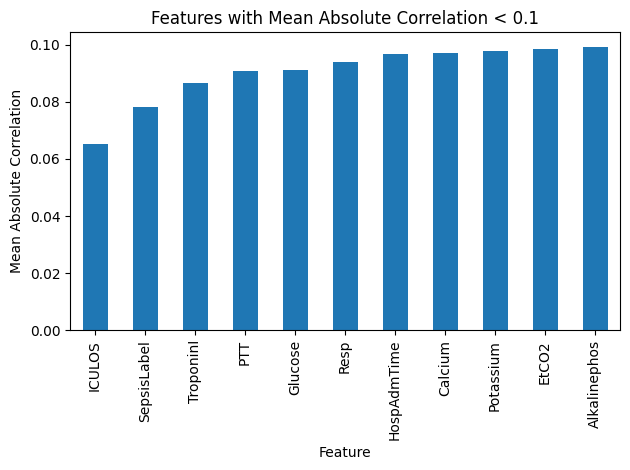

,feature,mean_abs_correlation
0,ICULOS,0.065119
1,SepsisLabel,0.078202
2,TroponinI,0.086775
3,PTT,0.090650
4,Glucose,0.091241
5,Resp,0.093905
6,HospAdmTime,0.096753
7,Calcium,0.097067
8,Potassium,0.097944
9,EtCO2,0.098410


In [11]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
import glob, os

numeric_val=df_val.select_dtypes(include='number').drop(columns=['Hour','Patient_ID','Unnamed: 0'],
                                                        errors='ignore')

corr_matrix=numeric_val.corr().abs()
mean_corr=corr_matrix.mean().sort_values()
low_corr_features=mean_corr[mean_corr<0.10]

plt.figure()
low_corr_features.plot(kind='bar')
plt.title('Features with Mean Absolute Correlation < 0.1')
plt.xlabel('Feature')
plt.ylabel('Mean Absolute Correlation')
plt.tight_layout()
plt.show()

selected_20=mean_corr.head(20).index.tolist()
final_cols=['Patient_ID','Hour']+selected_20

train_sel=df_train[final_cols]
val_sel=df_val[final_cols]
test_sel=df_test[final_cols]

train_grouped={pid:grp.sort_values('Hour')for pid,grp in train_sel.groupby('Patient_ID')}
val_grouped={pid:grp.sort_values('Hour')for pid,grp in val_sel.groupby('Patient_ID')}
test_grouped={pid:grp.sort_values('Hour')for pid,grp in test_sel.groupby('Patient_ID')}

low_corr_df=mean_corr.head(20).reset_index()
low_corr_df.columns=['feature','mean_abs_correlation']
display(low_corr_df)

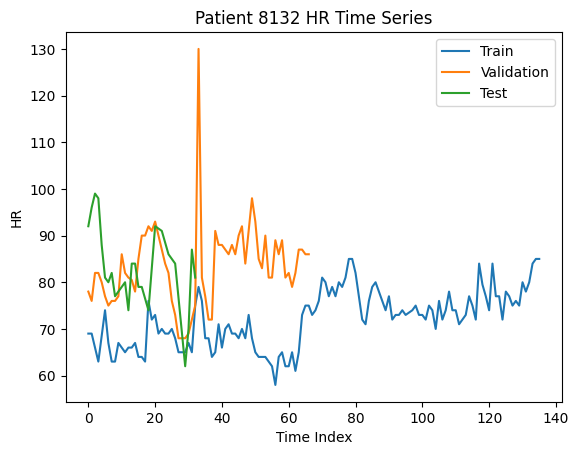

Random Patient_ID: 8132
Differencing order d until p ≤ 0.05: 1
Final ADF p-value: 0.0000


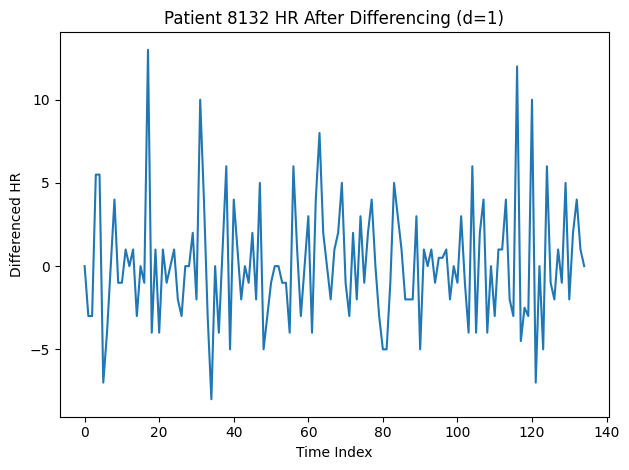

In [66]:
import random
from statsmodels.tsa.stattools import adfuller

common_patients=set(train_grouped.keys())&set(val_grouped.keys())&set(test_grouped.keys())
patient_id=random.choice(list(common_patients))

train_hr=train_grouped[patient_id]['HR'].values
val_hr=val_grouped[patient_id]['HR'].values
test_hr=test_grouped[patient_id]['HR'].values

plt.figure()
plt.plot(train_hr,label='Train')
plt.plot(val_hr,label='Validation')
plt.plot(test_hr,label='Test')
plt.title(f'Patient {patient_id} HR Time Series')
plt.xlabel('Time Index')
plt.ylabel('HR')
plt.legend()
plt.show()

def difference_until_stationary(series,alpha=0.05):
    d=0
    s=series.copy()
    pvalue=adfuller(s.dropna(),autolag='AIC')[1]
    while pvalue>alpha:
        s=s.diff().dropna()
        d+=1
        pvalue=adfuller(s,autolag='AIC')[1]
    return s,d,pvalue

train_series=train_grouped[patient_id]['HR']
stationary_series,d,final_p=difference_until_stationary(train_series)

print(f"Random Patient_ID: {patient_id}")
print(f"Differencing order d until p ≤ 0.05: {d}")
print(f"Final ADF p-value: {final_p:.4f}")

plt.figure()
plt.plot(stationary_series.values)
plt.title(f'Patient {patient_id} HR After Differencing (d={d})')
plt.xlabel('Time Index')
plt.ylabel('Differenced HR')
plt.tight_layout()
plt.show()

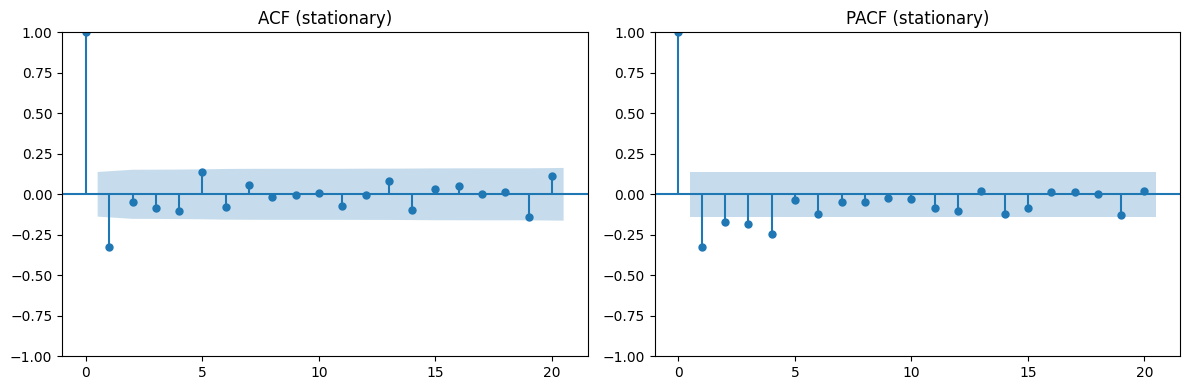

Selected orders: p=5 from PACF, d=1, q=2 from ACF


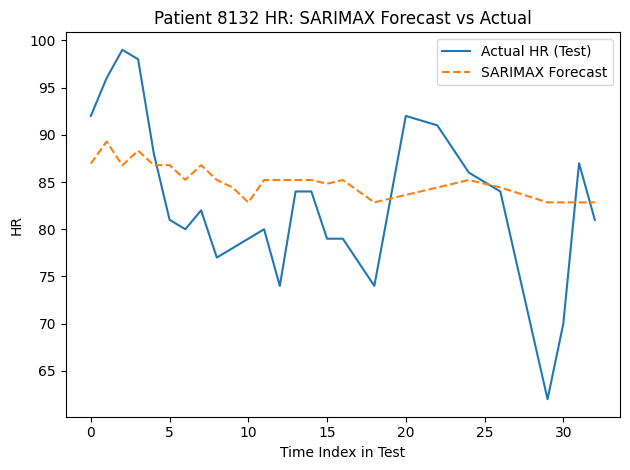

Test R² score: 0.1222


In [67]:
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
from sklearn.metrics import r2_score

train_hr=train_grouped[patient_id]['HR']
val_hr=val_grouped[patient_id]['HR']
test_hr=test_grouped[patient_id]['HR']

train_o2=train_grouped[patient_id]['O2Sat']
val_o2=val_grouped[patient_id]['O2Sat']
test_o2=test_grouped[patient_id]['O2Sat']

endog_train=pd.concat([train_hr,val_hr]).reset_index(drop=True)
exog_train=pd.concat([train_o2,val_o2]).reset_index(drop=True)

def get_d_and_stationary(series,alpha=0.05):
    d=0
    s=series.copy().dropna()
    p=adfuller(s,autolag='AIC')[1]
    while p>alpha:
        s=s.diff().dropna()
        d+=1
        p=adfuller(s,autolag='AIC')[1]
    return d,s

d,stationary_train=get_d_and_stationary(endog_train)

fig,axes=plt.subplots(1,2,figsize=(12,4))
plot_acf(stationary_train,lags=20,ax=axes[0],title='ACF (stationary)')
plot_pacf(stationary_train,lags=20,ax=axes[1],title='PACF (stationary)')
plt.tight_layout()
plt.show()

n=len(stationary_train)
conf_thr=2/np.sqrt(n)
acf_vals=acf(stationary_train,nlags=20)
pacf_vals=pacf(stationary_train,nlags=20)
p=next((i for i in range(1,len(pacf_vals)) if abs(pacf_vals[i])<conf_thr),1)
q=next((i for i in range(1,len(acf_vals)) if abs(acf_vals[i])<conf_thr),1)

print(f"Selected orders: p={p} from PACF, d={d}, q={q} from ACF")

SARIMAX_model=SARIMAX(endog_train,exog=exog_train,order=(p,d,q),enforce_stationarity=False
              ,enforce_invertibility=False)
res=SARIMAX_model.fit(disp=False)
pred=res.forecast(steps=len(test_hr), exog=test_o2)

plt.figure()
plt.plot(test_hr.values,label='Actual HR (Test)')
plt.plot(pred.values,label='SARIMAX Forecast', linestyle='--')
plt.title(f'Patient {patient_id} HR: SARIMAX Forecast vs Actual')
plt.xlabel('Time Index in Test')
plt.ylabel('HR')
plt.legend()
plt.tight_layout()
plt.show()

y_true=test_hr.dropna().reset_index(drop=True)
y_pred=pred.reset_index(drop=True)

min_len=min(len(y_true),len(y_pred))
y_true=y_true.iloc[:min_len]
y_pred=y_pred.iloc[:min_len]

r2=r2_score(y_true,y_pred)
print(f"Test R² score: {r2:.4f}")

In [31]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

feature_scaler=MinMaxScaler().fit(df_train[selected_20])

train_normalized=df_train.copy()
train_normalized[selected_20]=feature_scaler.transform(df_train[selected_20])

val_normalized=df_val.copy()
val_normalized[selected_20]=feature_scaler.transform(df_val[selected_20])

test_normalized=df_test.copy()
test_normalized[selected_20]=feature_scaler.transform(df_test[selected_20])

def normalize_hour_per_patient(df):
    df = df.copy()
    df['Hour'] = df.groupby('Patient_ID')['Hour'].transform(
        lambda x: (x-x.min())/(x.max()-x.min()))
    return df

train_normalized=normalize_hour_per_patient(train_normalized)
val_normalized=normalize_hour_per_patient(val_normalized)
test_normalized=normalize_hour_per_patient(test_normalized)

train_grouped={pid:grp.sort_values('Hour') for pid,grp in train_normalized.groupby('Patient_ID')}
val_grouped={pid:grp.sort_values('Hour') for pid,grp in val_normalized.groupby('Patient_ID')}
test_grouped={pid:grp.sort_values('Hour') for pid,grp in test_normalized.groupby('Patient_ID')}


# آموزش مدل‌های یادگیری عمیق

In [32]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller, acf, pacf

T_in=6
T_out=1

print(f"Chosen window sizes: T_in={T_in},T_out={T_out}")

def make_io_windows(grouped,feature_cols,T_in,T_out):
    X_list,Y_list=[],[]
    for df in grouped.values():
        data=df[feature_cols].values
        L=len(data)
        for start in range(0,L-T_in-T_out+1):
            end_in=start+T_in
            end_out=end_in+T_out
            X_list.append(data[start:end_in])
            Y_list.append(data[end_in:end_out])
    return np.stack(X_list),np.stack(Y_list)

feature_cols=[c for c in train_sel.columns if c not in ['Patient_ID','Hour']]

X_train,Y_train=make_io_windows(train_grouped,feature_cols,T_in,T_out)
X_val,Y_val=make_io_windows(val_grouped,feature_cols,T_in,T_out)
X_test,Y_test=make_io_windows(test_grouped,feature_cols,T_in,T_out)

print("X_train shape:",X_train.shape)
print("Y_train shape:",Y_train.shape)

Chosen window sizes: T_in=6,T_out=1
X_train shape: (35358, 6, 20)
Y_train shape: (35358, 1, 20)


In [46]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

df_all=pd.concat([df_train,df_val,df_test])

unique_patients=df_all['Patient_ID'].unique()
print(f"Total unique patients: {len(unique_patients)}")

train_patients,temp_patients=train_test_split(
    unique_patients,test_size=0.3,random_state=42)
val_patients,test_patients=train_test_split(
    temp_patients,test_size=0.5,random_state=42)

train_df=df_all[df_all['Patient_ID'].isin(train_patients)]
val_df=df_all[df_all['Patient_ID'].isin(val_patients)]
test_df=df_all[df_all['Patient_ID'].isin(test_patients)]

Total unique patients: 656


In [47]:
from sklearn.preprocessing import MinMaxScaler

def normalize_data_split(train_df,val_df,test_df,selected_20):
    feature_scaler=MinMaxScaler()
    feature_scaler.fit(train_df[selected_20])
    
    train_norm=train_df.copy()
    val_norm=val_df.copy()
    test_norm=test_df.copy()
    
    train_norm[selected_20]=feature_scaler.transform(train_df[selected_20])
    val_norm[selected_20]=feature_scaler.transform(val_df[selected_20])
    test_norm[selected_20]=feature_scaler.transform(test_df[selected_20])
    
    def normalize_hour(df):
        df=df.copy()
        df['Hour']=df.groupby('Patient_ID')['Hour'].transform(
            lambda x:(x-x.min())/(x.max()-x.min()) if x.max()>x.min() else 0.5)
        return df
    
    return normalize_hour(train_norm),normalize_hour(val_norm),normalize_hour(test_norm),feature_scaler

train_normalized,val_normalized,test_normalized,feature_scaler=normalize_data_split(
    train_df,val_df,test_df,selected_20)

In [48]:
train_grouped={pid:grp.sort_values('Hour') for pid,grp in train_normalized.groupby('Patient_ID')}
val_grouped={pid:grp.sort_values('Hour') for pid,grp in val_normalized.groupby('Patient_ID')}
test_grouped={pid:grp.sort_values('Hour') for pid,grp in test_normalized.groupby('Patient_ID')}

for set1,set2 in [('Train','Val'),('Train','Test'),('Val','Test')]:
    common=set(eval(f"{set1.lower()}_grouped.keys()")) & set(eval(f"{set2.lower()}_grouped.keys()"))
    print(f"Common {set1}-{set2} patients: {len(common)}")

Common Train-Val patients: 0
Common Train-Test patients: 0
Common Val-Test patients: 0


In [49]:
def create_windows_from_grouped(grouped_dict,T_in,T_out):
    X,y=[],[]
    for pid,df in grouped_dict.items():
        data=df[selected_20].values
        for start_idx in range(len(df)-T_in-T_out+1):
            X.append(data[start_idx:start_idx+T_in])
            y.append(data[start_idx+T_in:start_idx+T_in+T_out])
    return np.array(X),np.array(y)

X_train,Y_train=create_windows_from_grouped(train_grouped,T_in,T_out)
X_val,Y_val=create_windows_from_grouped(val_grouped,T_in,T_out)
X_test,Y_test=create_windows_from_grouped(test_grouped,T_in,T_out)

print(f"\nFinal dataset sizes:")
print(f"Train: {X_train.shape},{Y_train.shape}")
print(f"Val: {X_val.shape},{Y_val.shape}")
print(f"Test: {X_test.shape},{Y_test.shape}")


Final dataset sizes:
Train: (28468, 6, 20),(28468, 1, 20)
Val: (5251, 6, 20),(5251, 1, 20)
Test: (5572, 6, 20),(5572, 1, 20)


Epoch 1/40
445/445 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0590 - mae: 0.1130 - val_loss: 0.0089 - val_mae: 0.0719 - learning_rate: 0.0050
Epoch 2/40
445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0025 - mae: 0.0333 - val_loss: 0.0054 - val_mae: 0.0560 - learning_rate: 0.0050
Epoch 3/40
445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0020 - mae: 0.0287 - val_loss: 0.0064 - val_mae: 0.0675 - learning_rate: 0.0050
Epoch 4/40
445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0020 - mae: 0.0275 - val_loss: 0.0035 - val_mae: 0.0426 - learning_rate: 0.0050
Epoch 5/40
445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0019 - mae: 0.0269 - val_loss: 0.0049 - val_mae: 0.0550 - learning_rate: 0.0050
Epoch 6/40
445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0019 - mae: 0.0261 - val_loss: 0.0056 - val_mae: 0.0561 - learning_rate: 0.0050
Epoch 7/40
445/445 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0018 - mae: 0.0255 - val_loss: 0.0044 - val_mae: 0.0480 - learning_rate: 0.0050
Epoch 

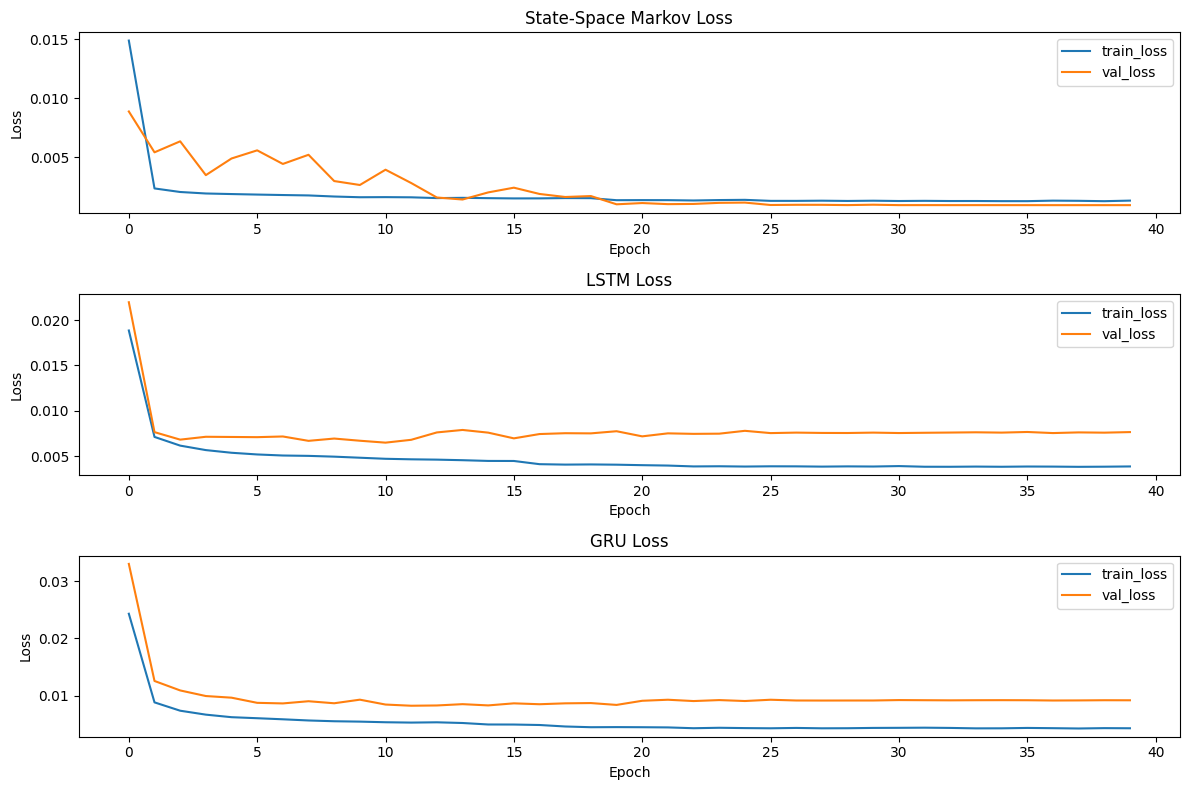

In [38]:
lr_scheduler1=tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                                  factor=0.2,patience=5,min_lr=1e-8)
lr_scheduler2=tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                                  factor=0.2,patience=5,min_lr=1e-8)
lr_scheduler3=tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                                  factor=0.2,patience=5,min_lr=1e-8)
lr_scheduler4=tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                                  factor=0.2,patience=4,min_lr=1e-8)
lr_scheduler5=tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                                  factor=0.2,patience=5,min_lr=1e-8)
history_ss=ss_markov_model.fit(
    X_train,Y_train[:,0,:],
    validation_data=(X_val,Y_val[:,0,:]),
    epochs=40,batch_size=batch_size,
    callbacks=[lr_scheduler1])

history_lstm=LSTM_model.fit(
    X_train,Y_train,
    validation_data=(X_val,Y_val),
    epochs=40,batch_size=batch_size,
    callbacks=[lr_scheduler2])
history_gru=GRU_model.fit(
    X_train,Y_train,
    validation_data=(X_val,Y_val),
    epochs=40,batch_size=batch_size,
    callbacks=[lr_scheduler3])


plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
plt.plot(history_ss.history['loss'],label='train_loss')
plt.plot(history_ss.history['val_loss'],label='val_loss')
plt.title('State-Space Markov Loss')
plt.xlabel('Epoch');plt.ylabel('Loss')
plt.legend()

plt.subplot(3,1,2)
plt.plot(history_lstm.history['loss'],label='train_loss')
plt.plot(history_lstm.history['val_loss'],label='val_loss')
plt.title('LSTM Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend()

plt.subplot(3,1,3)
plt.plot(history_gru.history['loss'],label='train_loss')
plt.plot(history_gru.history['val_loss'],label='val_loss')
plt.title('GRU Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

Epoch 1/40
445/445 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - loss: 0.0647 - mae: 0.1423 - val_loss: 0.0188 - val_mae: 0.0941 - learning_rate: 0.0050
Epoch 2/40
445/445 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - loss: 0.0055 - mae: 0.0487 - val_loss: 0.0055 - val_mae: 0.0482 - learning_rate: 0.0050
Epoch 3/40
445/445 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 0.0042 - mae: 0.0419 - val_loss: 0.0048 - val_mae: 0.0401 - learning_rate: 0.0050
Epoch 4/40
445/445 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - loss: 0.0037 - mae: 0.0383 - val_loss: 0.0053 - val_mae: 0.0407 - learning_rate: 0.0050
Epoch 5/40
445/445 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 0.0035 - mae: 0.0370 - val_loss: 0.0045 - val_mae: 0.0398 - learning_rate: 0.0050
Epoch 6/40
445/445 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 0.0032 - mae: 0.0347 - val_loss: 0.0053 - val_mae: 0.0413 - learning_rate: 0.0050
Epoch 7/40
445/445 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - loss: 0.0031 - mae: 0.0338 - val_loss: 0.0050 - val_mae: 0.0388 - learning_rate:

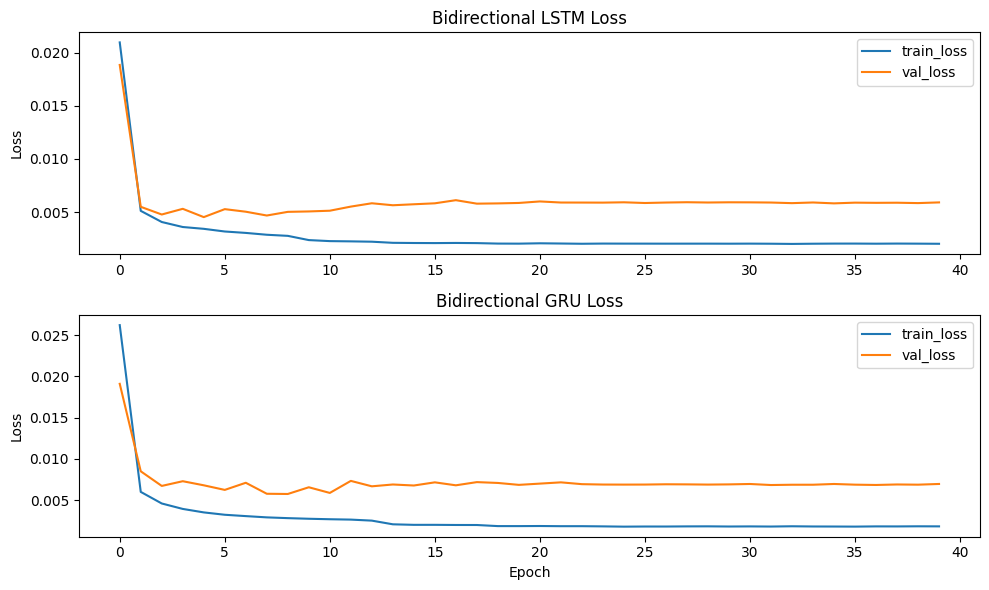

In [53]:
epochs=40
batch_size=64

history_bi_lstm=Bidirectional_LSTM_model.fit(
    X_train,Y_train,
    validation_data=(X_val,Y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1,
    callbacks=[lr_scheduler4])

history_bi_gru=Bidirectional_GRU_model.fit(
    X_train,Y_train,
    validation_data=(X_val,Y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1,
    callbacks=[lr_scheduler5])

plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.plot(history_bi_lstm.history['loss'],label='train_loss')
plt.plot(history_bi_lstm.history['val_loss'],label='val_loss')
plt.title('Bidirectional LSTM Loss')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2,1,2)
plt.plot(history_bi_gru.history['loss'], label='train_loss')
plt.plot(history_bi_gru.history['val_loss'],label='val_loss')
plt.title('Bidirectional GRU Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


# رسم نتایج و تحلیل جواب‌ها

In [57]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.spatial.distance import cosine

patient_id=next(iter(test_grouped.keys()))
df=test_grouped[patient_id]

X_pat,Y_pat=[],[]
data=df[selected_20].values
for i in range(len(data)-T_in-T_out+1):
    X_pat.append(data[i:i+T_in])
    Y_pat.append(data[i+T_in:i+T_in+T_out])
X_pat=np.stack(X_pat)
Y_pat=np.stack(Y_pat)

hr_idx=selected_20.index('HR')
y_true=Y_pat[:,0,hr_idx]

hr_idx=selected_20.index('HR')
y_true_all=Y_test[:,0,hr_idx]

y_pred_m=ss_markov_model.predict(X_test)[:,hr_idx]
y_pred_l=LSTM_model.predict(X_test)[:,0,hr_idx]
y_pred_g=GRU_model.predict(X_test)[:,0,hr_idx]
y_pred_bl=Bidirectional_LSTM_model.predict(X_test)[:,0,hr_idx]
y_pred_bg=Bidirectional_GRU_model.predict(X_test)[:,0,hr_idx]

# 3) Compute metrics
def metrics_dict(y_t, y_p):
    return {
      'MSE': mean_squared_error(y_t, y_p),
      'MAE': mean_absolute_error(y_t, y_p),
      'R2':  r2_score(y_t, y_p),
      'CosDist': cosine(y_t, y_p)
    }

met_all = {
  'Markov': metrics_dict(y_true_all, y_pred_m),
  'LSTM':   metrics_dict(y_true_all, y_pred_l),
  'GRU':    metrics_dict(y_true_all, y_pred_g),
  'Bi-LSTM':metrics_dict(y_true_all, y_pred_bl),
  'Bi-GRU': metrics_dict(y_true_all, y_pred_bg),
}

# 4) Print in a tidy table
print("Model     |    MSE   |    MAE   |    R2    | CosDist")
for name, m in met_all.items():
    print(f"{name:8s} | {m['MSE']:8.4f} | {m['MAE']:8.4f} | {m['R2']:8.4f} | {m['CosDist']:8.4f}")


175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Model     |    MSE   |    MAE   |    R2    | CosDist
Markov   |   0.0014 |   0.0255 |   0.8454 |   0.0070
LSTM     |   0.0076 |   0.0701 |   0.1863 |   0.0208
GRU      |   0.0074 |   0.0688 |   0.2096 |   0.0182
Bi-LSTM  |   0.0073 |   0.0705 |   0.2217 |   0.0157
Bi-GRU   |   0.0086 |   0.0803 |   0.0814 |   0.0100


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


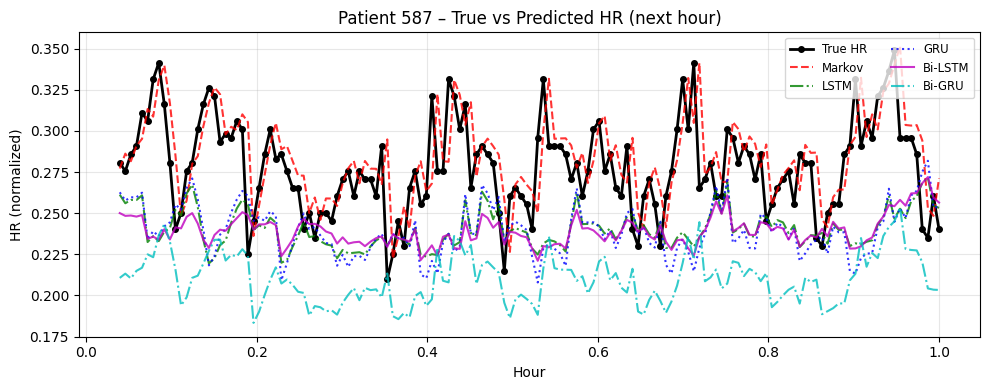

In [55]:
import matplotlib.pyplot as plt
import numpy as np

patient_id=next(iter(test_grouped.keys()))
df=test_grouped[patient_id]

X_pat,Y_pat=[],[]
data=df[selected_20].values
for i in range(len(data)-T_in-T_out+1):
    X_pat.append(data[i:i+T_in])
    Y_pat.append(data[i+T_in:i+T_in+T_out])
X_pat=np.stack(X_pat)
Y_pat=np.stack(Y_pat)

hr_idx=selected_20.index('HR')
y_true=Y_pat[:,0,hr_idx]

hours=df['Hour'].values         
hours_pred=hours[T_in:T_in+len(y_true)]

y_m=ss_markov_model.predict(X_pat)[:,hr_idx]
y_l=LSTM_model.predict(X_pat)[:,0,hr_idx]
y_g=GRU_model.predict(X_pat)[:,0,hr_idx]
y_bl=Bidirectional_LSTM_model.predict(X_pat)[:,0,hr_idx]
y_bg=Bidirectional_GRU_model.predict(X_pat)[:,0,hr_idx]

plt.figure(figsize=(10,4))
plt.plot(hours_pred,y_true,'-ok',label='True HR',linewidth=2,markersize=4)
plt.plot(hours_pred,y_m,'--r',label='Markov',alpha=0.8)
plt.plot(hours_pred,y_l,'-.g',label='LSTM',alpha=0.8)
plt.plot(hours_pred,y_g,':b',label='GRU',alpha=0.8)
plt.plot(hours_pred,y_bl,'-m',label='Bi-LSTM',alpha=0.8)
plt.plot(hours_pred,y_bg,'-.c',label='Bi-GRU',alpha=0.8)

plt.title(f'Patient {patient_id} – True vs Predicted HR (next hour)')
plt.xlabel('Hour')
plt.ylabel('HR (normalized)')
plt.legend(loc='upper right',fontsize='small',ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Maximum Log-Likelihood Estimation

In [102]:
def weighted_mse(y_true, y_pred):
    true_mu=y_true[..., :20]
    true_var=y_true[..., 20:]
    pred_mu=y_pred[..., :20]
    pred_var=y_pred[..., 20:]

    mse_mu=K.mean(K.square(pred_mu-true_mu)) 
    mse_var=K.mean(K.square(pred_var-true_var)) 
    return mse_mu + 10.0*mse_var 

In [103]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Reshape, Lambda
import tensorflow as tf
import tensorflow.keras.backend as K

def build_LSTM_network(T_in,output_window,num_features):
    
    inputs=Input(shape=(T_in,num_features))

    x=LSTM(64,return_sequences=True)(inputs)
    x=LSTM(32)(x)
    
    mean_output=Dense(output_window*num_features,activation='linear')(x)
    var_output=Dense(output_window*num_features,activation='softplus')(x)
    
    mean_reshape=Reshape((output_window,num_features))(mean_output)
    var_reshape=Reshape((output_window,num_features))(var_output)
    
    outputs=Concatenate(axis=-1)([mean_reshape,var_reshape])
    
    return Model(inputs=inputs,outputs=outputs)

T_in=6
output_window=6
num_features=20

model=build_LSTM_network(T_in, output_window, num_features)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(0.005),loss=weighted_mse)

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_21            │ (None, 6, 20)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_27 (LSTM)            │ (None, 6, 64)          │         21,760 │ input_layer_21[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_28 (LSTM)            │ (None, 32)             │         12,416 │ lstm_27[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_42 (Dense)          │ (None, 120)            │          3,960 │ lstm_28[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_43 (Dense)          │ (None, 120)            │          3,960 │ lstm_28[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_24 (Reshape)      │ (None, 6, 20)          │              0 │ dense_42[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_25 (Reshape)      │ (None, 6, 20)          │              0 │ dense_43[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_12            │ (None, 6, 40)          │              0 │ reshape_24[0][0],      │
│ (Concatenate)             │                        │                │ reshape_25[0][0]       │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 42,096 (164.44 KB)

 Trainable params: 42,096 (164.44 KB)

 Non-trainable params: 0 (0.00 B)

In [104]:
T_out=6
X_train,Y_train=create_windows_from_grouped(train_grouped,T_in,T_out)
X_val,Y_val=create_windows_from_grouped(val_grouped,T_in,T_out)
X_test,Y_test=create_windows_from_grouped(test_grouped,T_in,T_out)


def make_moment_targets(Y_raw):
    N,T_out,n_feats=Y_raw.shape
    Y_mom=np.zeros((N,T_out,2*n_feats),dtype=np.float32)

    for i in range(N):
        slice_raw=Y_raw[i]              
        mu_vec=np.mean(slice_raw,axis=0)    
        var_vec=np.var(slice_raw,axis=0)

        for t in range(T_out):
            Y_mom[i,t,:n_feats]=mu_vec
            Y_mom[i,t,n_feats:]=var_vec

    return Y_mom

Y_train_mom=make_moment_targets(Y_train) 
Y_val_mom=make_moment_targets(Y_val)
Y_test_mom=make_moment_targets(Y_test) 

print("\nMoment‐target shapes:")
print(" Y_train_mom:",Y_train_mom.shape)
print(" Y_val_mom:",Y_val_mom.shape)
print(" Y_test_mom:",Y_test_mom.shape)



Moment‐target shapes:
 Y_train_mom: (26405, 6, 40)
 Y_val_mom: (4819, 6, 40)
 Y_test_mom: (5142, 6, 40)


Epoch 1/40
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.4251 - val_loss: 0.0254 - learning_rate: 0.0050
Epoch 2/40
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0263 - val_loss: 0.0250 - learning_rate: 0.0050
Epoch 3/40
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0259 - val_loss: 0.0249 - learning_rate: 0.0050
Epoch 4/40
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0242 - val_loss: 0.0126 - learning_rate: 0.0050
Epoch 5/40
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0135 - val_loss: 0.0127 - learning_rate: 0.0050
Epoch 6/40
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0134 - val_loss: 0.0125 - learning_rate: 0.0050
Epoch 7/40
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0190 - val_loss: 0.0124 - learning_rate: 0.0050
Epoch 8/40
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0131 - val_loss: 0.0110 - learning_rate: 0.0050
Epoch 9/40
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0110 - val_loss: 0.0085 - learning_rate: 0.0050
Epoch 10/4

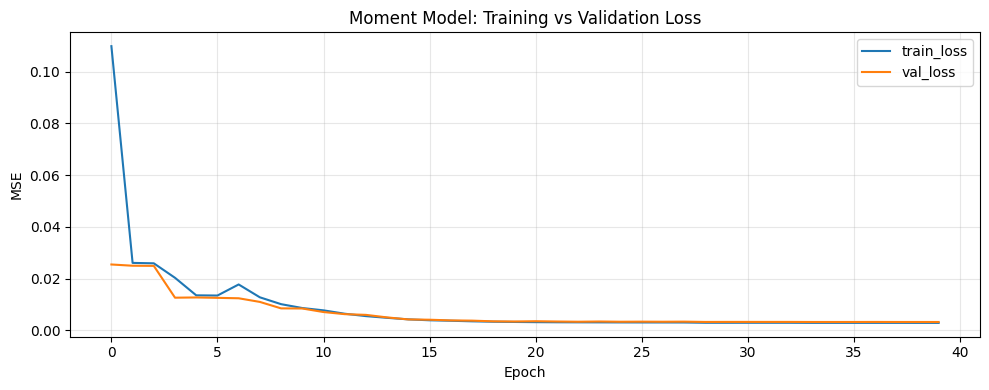

In [105]:
batch_size=64
epochs=40
lr_scheduler6=tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                                  factor=0.2,patience=5,min_lr=1e-8)
history=model.fit(
    X_train,Y_train_mom,
    validation_data=(X_val,Y_val_mom),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1,
    callbacks=[lr_scheduler6])

plt.figure(figsize=(10,4))
plt.plot(history.history['loss'],   label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Moment Model: Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [106]:
import numpy as np
from sklearn.metrics import r2_score

Y_pred_mom=model.predict(X_test)

hr_idx=selected_20.index('HR')

y_true_hr=Y_test_mom[:,0,hr_idx]   
y_pred_hr=Y_pred_mom[:,0,hr_idx]   

r2_hr=r2_score(y_true_hr,y_pred_hr)
print(f"R² for HR mean (test set):{r2_hr:.4f}")

y_true_hr_var=Y_test_mom[:,0,num_features+hr_idx]
y_pred_hr_var=Y_pred_mom[:,0,num_features+hr_idx]
r2_hr_var=r2_score(y_true_hr_var,y_pred_hr_var)
print(f"R² for HR variance (test set):{r2_hr_var:.4f}")

y_true_all=Y_test_mom.reshape(-1) 
y_pred_all=Y_pred_mom.reshape(-1)  

r2_all=r2_score(y_true_all,y_pred_all)
print(f"R² for all means+variances combined (test set):{r2_all:.4f}")

161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
R² for HR mean (test set):0.8597
R² for HR variance (test set):-0.0027
R² for all means+variances combined (test set):0.9885


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.spatial.distance import cosine

T_in=6
T_out=6
num_features=len(selected_20)

hr_idx=selected_20.index('HR')

def add_laplace_noise_to_hr(df,hr_col='HR',scale=0.05):
    df_noisy=df.copy()
    hr_clean=df_noisy[hr_col].values
    noise=np.random.laplace(loc=0.0,scale=scale,size=hr_clean.shape)
    df_noisy[hr_col]=np.clip(hr_clean+noise,0.0,1.0)
    return df_noisy

patient_id=list(test_grouped_corrected.keys())[0]
print(f"Selected Patient ID:{patient_id}")

df_clean=test_grouped[patient_id].copy()

laplace_scale=0.05
df_noisy=add_laplace_noise_to_hr(df_clean,hr_col='HR',scale=laplace_scale)

print(f"Total time steps for patient {patient_id}: {len(df_clean)}")

data_noisy=df_noisy[selected_20].values 
N_hours=data_noisy.shape[0]
N_windows=N_hours-T_in+1 


N_valid_windows=N_hours-T_in-T_out+1

X_noisy_windows=np.zeros((N_valid_windows,T_in,num_features),dtype=np.float32)

for i in range(N_valid_windows):
    X_noisy_windows[i]=data_noisy[i:i+T_in]

print("X_noisy_windows shape:",X_noisy_windows.shape)  


def recursive_bi_lstm_block_forecast(model,input_window,block_size):
    window=input_window.copy() 
    hr_block=[]
    
    for _ in range(block_size):

        raw_pred=model.predict(window[np.newaxis, ...],verbose=0)  
     
        if raw_pred.ndim ==3 and raw_pred.shape[1] == 1:
            raw_pred=raw_pred[:,0,:]    
        raw_pred=raw_pred[0]             
        
        hr_next=raw_pred[hr_idx]
        hr_block.append(hr_next)
        
      
        window=np.vstack([window[1:],raw_pred[np.newaxis,:]])  
    
    return np.array(hr_block,dtype=np.float32)  


bi_pred_raw_hr_blocks = np.zeros((N_valid_windows, T_out), dtype=np.float32)

for i in range(N_valid_windows):
    input_win = X_noisy_windows[i]     
    hr_block = recursive_bi_lstm_block_forecast(bi_lstm_raw, input_win, block_size=T_out)
    bi_pred_raw_hr_blocks[i] = hr_block  

print("bi_pred_raw_hr_blocks shape:", bi_pred_raw_hr_blocks.shape)  


bi_pred_mean_hr=bi_pred_raw_hr_blocks.mean(axis=1)  
bi_pred_var_hr=bi_pred_raw_hr_blocks.var(axis=1)   


Y_pred_mom=model.predict(X_noisy_windows,batch_size=32)  

mom_pred_mean_hr=Y_pred_mom[:,0,hr_idx]      
mom_pred_var_hr=Y_pred_mom[:,0,num_features+hr_idx]  


hr_clean=df_clean['HR'].values 

true_mean_hr=[]
true_var_hr=[]


for i in range(N_valid_windows):
    block_clean=hr_clean[i+T_in:i+T_in+T_out] 
    true_mean_hr.append(block_clean.mean())
    true_var_hr.append(block_clean.var())

true_mean_hr=np.array(true_mean_hr,dtype=np.float32)  
true_var_hr=np.array(true_var_hr,dtype=np.float32) 



hours=df_clean['Hour'].values 

hours_pred=hours[T_in:T_in+N_valid_windows]



plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(hours, hr_clean, 'k-', linewidth=2, label='True Clean HR')  
plt.plot(hours_pred, true_mean_hr,   '-.k',   label='True 6-hr Mean (Clean)')
plt.plot(hours_pred, bi_pred_mean_hr, '--r',  label='Bi-LSTM Rec. Forecast Mean')
plt.plot(hours_pred, mom_pred_mean_hr, '-.b', label='Moment Model Predicted Mean')

plt.ylabel('Normalized HR Mean')
plt.title(f'Patient {patient_id} – 6-Hour Block HR Mean Under Laplace Noise')
plt.legend(fontsize='small')
plt.grid(alpha=0.3)


plt.subplot(2, 1, 2)
plt.plot(hours_pred, true_var_hr,   '-.k',   label='True 6-hr Variance (Clean)')
plt.plot(hours_pred, bi_pred_var_hr, '--r',  label='Bi-LSTM Rec. Forecast Var')
plt.plot(hours_pred, mom_pred_var_hr, '-.b', label='Moment Model Predicted Var')

plt.ylabel('Normalized HR Variance')
plt.xlabel('Hour')
plt.title(f'Patient {patient_id} – 6-Hour Block HR Variance Under Laplace Noise')
plt.legend(fontsize='small')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
